In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
features_df = pd.read_parquet('../data/processed/fighters_features.parquet')
labeled_df = pd.read_parquet('../data/processed/fighters_clustered_labeled.parquet')
kmeans = joblib.load('../models/kmeans.pkl')

with open('../models/model_choice.json') as f:
    model_choice = json.load(f)

feature_cols = [c for c in features_df.columns if c.startswith('pc_')]
X = features_df[feature_cols].values

print('Feature matrix shape:', X.shape, '(PCA components used for clustering)')
print('Trained k:', model_choice['k_final'])
model_choice

Feature matrix shape: (3438, 6) (PCA components used for clustering)
Trained k: 4


{'k_final': 4,
 'k_silhouette_optimal': 3,
 'silhouette_by_k': {'3': 0.22565323579709068,
  '4': 0.22461693477937472,
  '5': 0.18944260404859378,
  '6': 0.19961841944979145,
  '7': 0.1975479714374515,
  '8': 0.19061359767606284},
 'kmeans_silhouette': 0.22461693477937472,
 'gmm_silhouette': 0.17144439017151156}

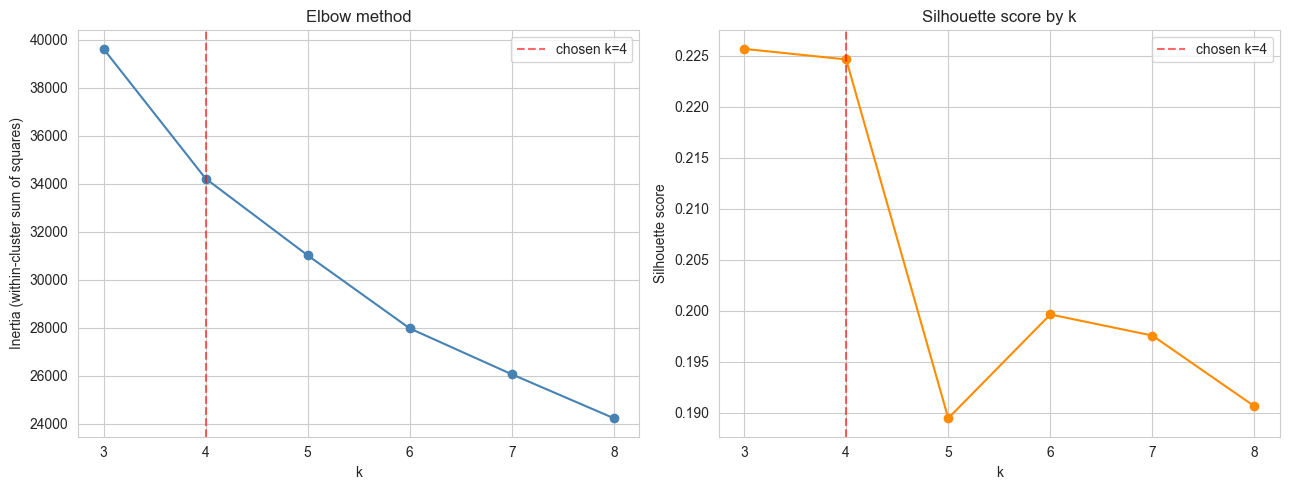

,k,inertia,silhouette
0,3,39628.029811,0.225653
1,4,34221.359719,0.224617
2,5,31020.110485,0.189443
3,6,27974.629266,0.199618
4,7,26061.246439,0.197548
5,8,24229.012426,0.190614


In [3]:
k_range = range(3, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method')
axes[0].axvline(model_choice['k_final'], color='red', linestyle='--', alpha=0.6, label=f"chosen k={model_choice['k_final']}")
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score by k')
axes[1].axvline(model_choice['k_final'], color='red', linestyle='--', alpha=0.6, label=f"chosen k={model_choice['k_final']}")
axes[1].legend()

plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouettes})

In [4]:
cluster_counts = labeled_df['cluster'].value_counts().sort_index()
cluster_labels_map = labeled_df.groupby('cluster')['cluster_label'].first()

summary = pd.DataFrame({
    'label': cluster_labels_map,
    'count': cluster_counts,
    'pct': (cluster_counts / len(labeled_df) * 100).round(1),
})
summary

,label,count,pct
cluster,,,
0,Low Output / Weak Defense,990,28.8
1,Striker,1734,50.4
2,Wrestler / Grappler,666,19.4
3,Submission Specialist (Grappler),48,1.4


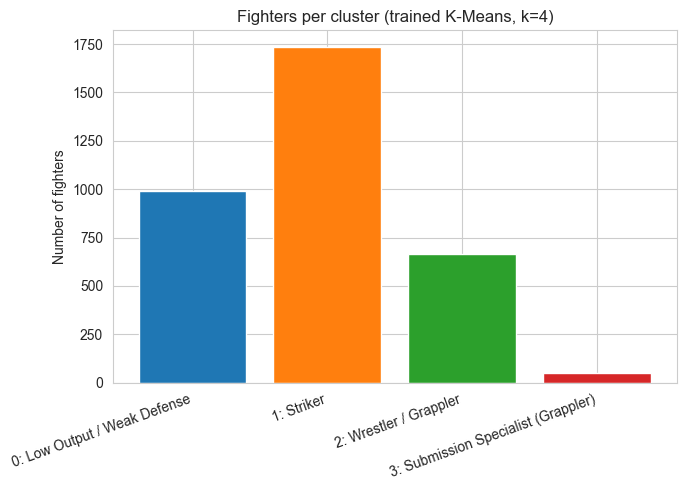

In [5]:
plt.figure(figsize=(7,5))
colors = sns.color_palette('tab10', n_colors=len(summary))
plt.bar(summary.index.astype(str) + ': ' + summary['label'], summary['count'], color=colors)
plt.ylabel('Number of fighters')
plt.title('Fighters per cluster (trained K-Means, k=4)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

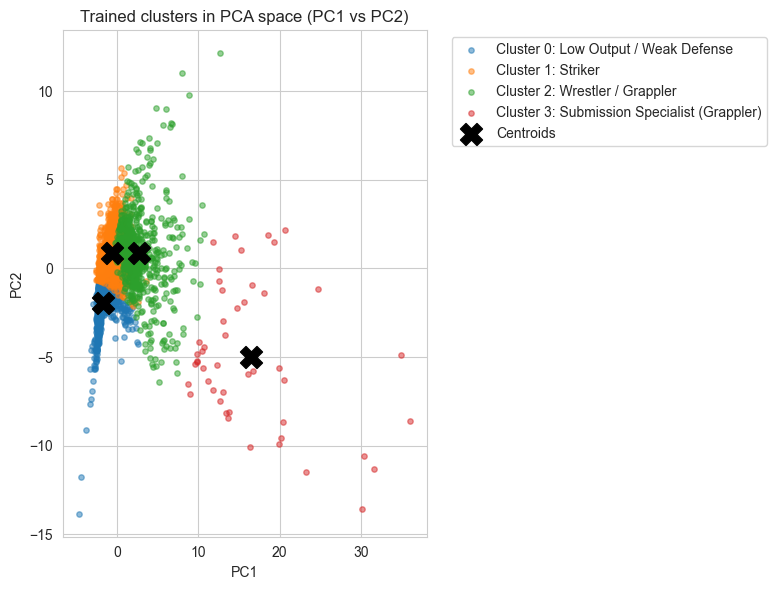

In [6]:
plt.figure(figsize=(8,6))
palette = sns.color_palette('tab10', n_colors=summary.shape[0])
for cluster_id in sorted(labeled_df['cluster'].unique()):
    mask = features_df.index[labeled_df['cluster'] == cluster_id]
    subset = features_df.loc[mask]
    label = cluster_labels_map[cluster_id]
    plt.scatter(subset['pc_1'], subset['pc_2'], s=15, alpha=0.5,
                color=palette[cluster_id], label=f'Cluster {cluster_id}: {label}')

# cluster centroids, projected onto the same first two PCA dimensions
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], s=250, c='black', marker='X', label='Centroids')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Trained clusters in PCA space (PC1 vs PC2)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
style_features = [
    'significant_strikes_landed_per_minute',
    'significant_striking_accuracy',
    'significant_strikes_absorbed_per_minute',
    'significant_strike_defence',
    'average_takedowns_landed_per_15_minutes',
    'takedown_accuracy',
    'takedown_defense',
    'average_submissions_attempted_per_15_minutes',
]

processed_df = pd.read_parquet('../data/processed/fighters_processed.parquet')
profile_df = pd.concat(
    [labeled_df[['cluster', 'cluster_label']].reset_index(drop=True),
     processed_df[style_features].reset_index(drop=True)],
    axis=1
)

profile = profile_df.groupby(['cluster', 'cluster_label'])[style_features].mean().round(2)
profile

,,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes
cluster,cluster_label,,,,,,,,
0,Low Output / Weak Defense,2.09,36.08,5.02,44.05,0.25,4.34,24.95,0.21
1,Striker,3.68,45.43,3.46,55.57,1.33,38.65,63.08,0.36
2,Wrestler / Grappler,2.23,44.71,2.77,49.57,3.69,52.95,37.21,1.72
3,Submission Specialist (Grappler),1.82,38.44,2.41,48.25,2.67,32.27,27.15,11.01


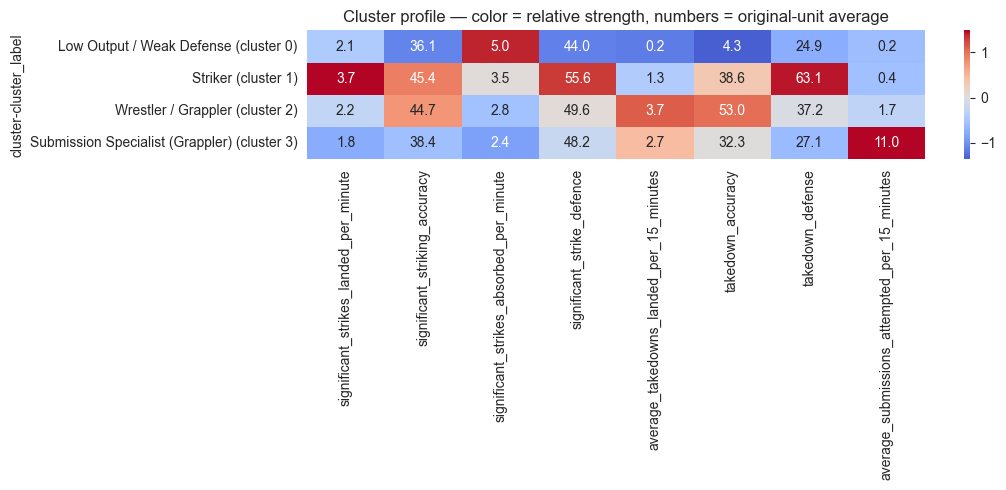

In [8]:
profile_z = profile.copy()
profile_z[style_features] = (profile[style_features] - profile[style_features].mean()) / profile[style_features].std()

plt.figure(figsize=(11,5))
sns.heatmap(profile_z[style_features], annot=profile[style_features].values, fmt='.1f',
            cmap='coolwarm', center=0,
            yticklabels=[f'{c[1]} (cluster {c[0]})' for c in profile.index])
plt.title('Cluster profile — color = relative strength, numbers = original-unit average')
plt.tight_layout()
plt.show()